# Ranking Objects from Pairwise Distances

Given a pairwise distance matrix, we want to rank objects in 1D. Several methods:

1. **PCA on distance matrix** - Project to 1D using first principal component
2. **Multidimensional Scaling (MDS)** - Classic method for distance matrices
3. **Principal Coordinate Analysis (PCoA)** - Similar to PCA but designed for distances
4. **Spectral embedding** - Use eigenvectors of distance/Laplacian matrix
5. **Linear programming** - Optimize for 1D embedding that preserves distances

In [1]:
import numpy as np

D1 = np.array(
    [
        [0.0, 0.427665, 1.171629, 1.818593, 2.189619],
        [0.428663, 0.0, 0.740754, 1.428485, 1.792835],
        [1.187607, 0.764262, 0.0, 0.675854, 0.990132],
        [1.927047, 1.506025, 0.753496, 0.0, 0.304562],
        [2.271512, 1.880707, 1.163831, 0.418902, 0.0],
    ]
)

D2 = np.array(
    [
        [0.0, 0.430051, 1.196057, 1.928269, 2.285559],
        [0.430368, 0.0, 0.760756, 1.494182, 1.862984],
        [1.195257, 0.766010, 0.0, 0.719315, 1.092578],
        [1.929690, 1.500239, 0.737282, 0.0, 0.361814],
        [2.305053, 1.877272, 1.109959, 0.381562, 0.0],
    ]
)

D3 = np.array(
    [
        [
            0.0,
            0.022891,
            0.427665,
            0.440544,
            1.171629,
            1.203825,
            1.818593,
            1.935536,
            2.189619,
            2.296158,
        ],
        [
            0.033992,
            0.0,
            0.421580,
            0.430051,
            1.172923,
            1.196057,
            1.867230,
            1.928269,
            2.208503,
            2.285559,
        ],
        [
            0.428663,
            0.424081,
            0.0,
            0.007419,
            0.740754,
            0.773458,
            1.428485,
            1.508515,
            1.792835,
            1.872011,
        ],
        [
            0.444485,
            0.430368,
            0.042329,
            0.0,
            0.740305,
            0.760756,
            1.434052,
            1.494182,
            1.774507,
            1.862984,
        ],
        [
            1.187607,
            1.181476,
            0.764262,
            0.763143,
            0.0,
            0.007527,
            0.675854,
            0.747153,
            0.990132,
            1.131135,
        ],
        [
            1.206721,
            1.195257,
            0.781641,
            0.766010,
            0.052543,
            0.0,
            0.664032,
            0.719315,
            1.004254,
            1.092578,
        ],
        [
            1.927047,
            1.927357,
            1.506025,
            1.510288,
            0.753496,
            0.750106,
            0.0,
            0.007537,
            0.304562,
            0.392804,
        ],
        [
            1.925521,
            1.929690,
            1.508407,
            1.500239,
            0.774283,
            0.737282,
            0.080154,
            0.0,
            0.282520,
            0.361814,
        ],
        [
            2.271512,
            2.341073,
            1.880707,
            1.926127,
            1.163831,
            1.163007,
            0.418902,
            0.399443,
            0.0,
            0.009256,
        ],
        [
            2.270676,
            2.305053,
            1.874230,
            1.877272,
            1.158255,
            1.109959,
            0.446873,
            0.381562,
            0.143278,
            0.0,
        ],
    ]
)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from sklearn.decomposition import PCA
from scipy.spatial.distance import squareform, pdist
from scipy.linalg import eigh
import warnings

warnings.filterwarnings("ignore")
symmetrized_dist_matrix = 1 / 2 * (D2 + D2.T)
print("Symmetrized distance matrix:")
print(symmetrized_dist_matrix)


Symmetrized distance matrix:
[[0.        0.4302095 1.195657  1.9289795 2.295306 ]
 [0.4302095 0.        0.763383  1.4972105 1.870128 ]
 [1.195657  0.763383  0.        0.7282985 1.1012685]
 [1.9289795 1.4972105 0.7282985 0.        0.371688 ]
 [2.295306  1.870128  1.1012685 0.371688  0.       ]]


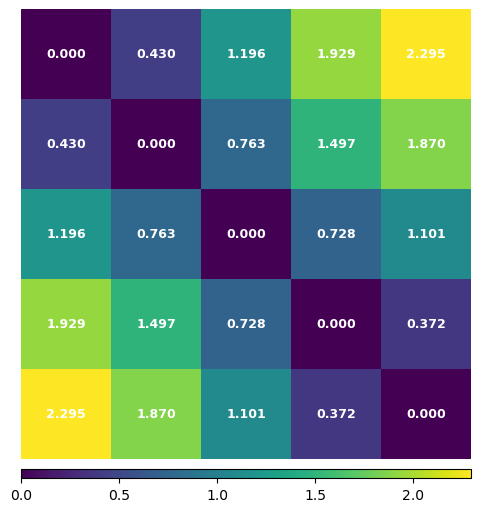

In [8]:
im = plt.imshow(symmetrized_dist_matrix)
ax = plt.gca()
plt.axis("off")

# Add value labels to first matrix
for i in range(symmetrized_dist_matrix.shape[0]):
    for j in range(symmetrized_dist_matrix.shape[1]):
        ax.text(
            j,
            i,
            f"{symmetrized_dist_matrix[i, j]:.3f}",
            ha="center",
            va="center",
            color="white",
            fontsize=9,
            weight="bold",
        )


# Apply tight_layout first to position the plot
plt.tight_layout()

# Get the position of the imshow plot after tight_layout
pos = ax.get_position()
# Create colorbar axes below the matrix that matches the width of the imshow plot
cbar_height = 0.02
cbar_pad = 0.02
cbar_ax = plt.gcf().add_axes(
    [pos.x0, pos.y0 - cbar_height - cbar_pad, pos.width, cbar_height]
)
cbar = plt.colorbar(im, cax=cbar_ax, orientation="horizontal")
plt.savefig("distance_matrix_rotational_tori.svg", dpi=300, bbox_inches="tight")
plt.show()

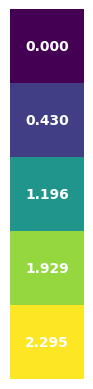

In [5]:
vmin, vmax = symmetrized_dist_matrix.min(), symmetrized_dist_matrix.max()
data = symmetrized_dist_matrix[0].reshape(-1, 1)
plt.imshow(data, vmin=vmin, vmax=vmax)
plt.axis("off")

# Add text labels in the center of each square
n_rows = data.shape[0]
mid = (vmin + vmax) / 2
for i in range(n_rows):
    plt.text(
        0,
        i,
        f"{data[i, 0]:.3f}",
        ha="center",
        va="center",
        color="white",
        fontsize=10,
        weight="bold",
    )

plt.savefig("rotational_tori_on_geodesic.svg", dpi=300, bbox_inches="tight")

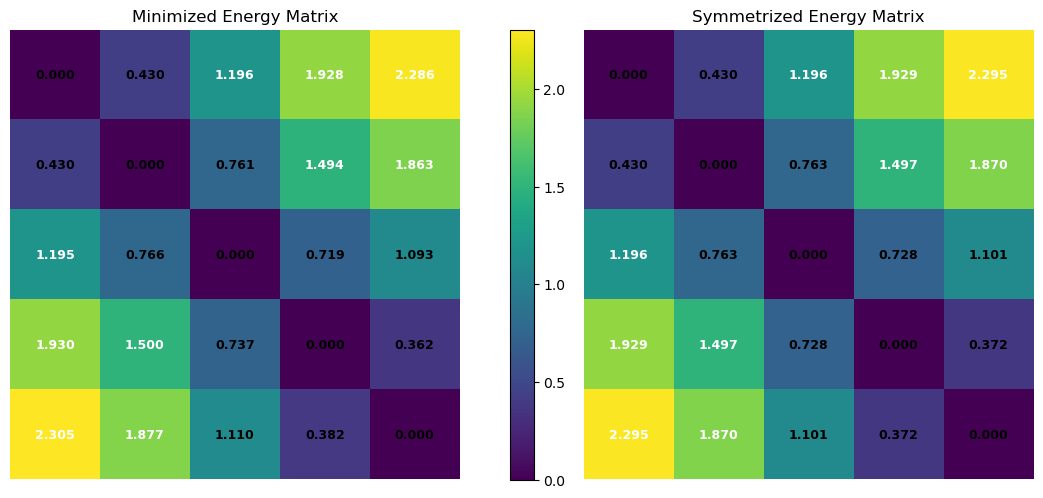

In [15]:
distance_matrix = D2
symmetrized_dist_matrix = 1 / 2 * (D2 + D2.T)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Determine shared colorbar limits
vmin = min(distance_matrix.min(), symmetrized_dist_matrix.min())
vmax = max(distance_matrix.max(), symmetrized_dist_matrix.max())

# Plot first matrix
im1 = ax1.imshow(distance_matrix, vmin=vmin, vmax=vmax)
ax1.set_title("Minimized Energy Matrix")
ax1.axis("off")

# Add value labels to first matrix
for i in range(distance_matrix.shape[0]):
    for j in range(distance_matrix.shape[1]):
        ax1.text(
            j,
            i,
            f"{distance_matrix[i, j]:.3f}",
            ha="center",
            va="center",
            color="white" if distance_matrix[i, j] > (vmin + vmax) / 2 else "black",
            fontsize=9,
            weight="bold",
        )

# Plot second matrix
im2 = ax2.imshow(symmetrized_dist_matrix, vmin=vmin, vmax=vmax)
ax2.set_title("Symmetrized Energy Matrix")
ax2.axis("off")

# Add value labels to second matrix
for i in range(symmetrized_dist_matrix.shape[0]):
    for j in range(symmetrized_dist_matrix.shape[1]):
        ax2.text(
            j,
            i,
            f"{symmetrized_dist_matrix[i, j]:.3f}",
            ha="center",
            va="center",
            color="white"
            if symmetrized_dist_matrix[i, j] > (vmin + vmax) / 2
            else "black",
            # color='white',
            fontsize=9,
            weight="bold",
        )

# Adjust subplot positions to make room for colorbar in the middle
plt.tight_layout()
# Get the positions of the two axes
pos1 = ax1.get_position()
pos2 = ax2.get_position()

# Calculate the middle position between the two subplots
cbar_x = (pos1.x1 + pos2.x0) / 2
cbar_width = 0.02
cbar_y = pos1.y0
cbar_height = pos1.height

# Create axes for colorbar in the middle
cbar_ax = fig.add_axes([cbar_x - cbar_width / 2, cbar_y, cbar_width, cbar_height])
cbar = fig.colorbar(im1, cax=cbar_ax, orientation="vertical")

plt.savefig("distance_matrix_rotational_tori.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# compute the column-wise subtractions
for j in range(1, symmetrized_dist_matrix.shape[1]):
    subtractions = symmetrized_dist_matrix[:, j] - symmetrized_dist_matrix[:, j - 1]
    print(subtractions)

[ 0.43  -0.43  -0.435 -0.395 -0.4  ]
[ 0.76   0.755 -0.755 -0.74  -0.72 ]
[ 0.69   0.73   0.745 -0.745 -0.74 ]
[ 0.365  0.36   0.38   0.385 -0.385]


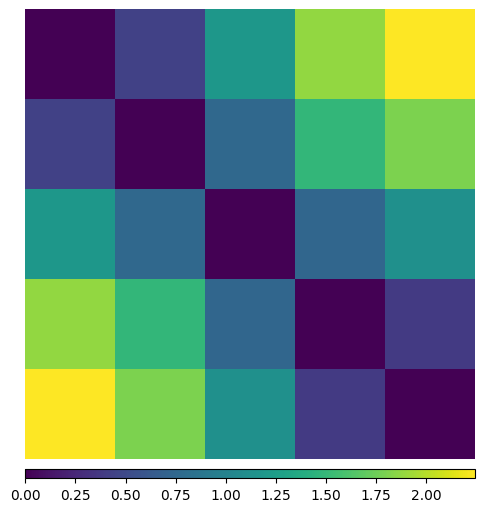

In [ ]:
im = plt.imshow(symmetrized_dist_matrix)
ax = plt.gca()
plt.axis("off")

# Apply tight_layout first to position the plot
plt.tight_layout()

# Get the position of the imshow plot after tight_layout
pos = ax.get_position()
# Create colorbar axes below the matrix that matches the width of the imshow plot
cbar_height = 0.02
cbar_pad = 0.02
cbar_ax = plt.gcf().add_axes(
    [pos.x0, pos.y0 - cbar_height - cbar_pad, pos.width, cbar_height]
)
cbar = plt.colorbar(im, cax=cbar_ax, orientation="horizontal")

# for i in range(symmetrized_dist_matrix.shape[0]):
#     for j in range(symmetrized_dist_matrix.shape[1]):
#         plt.text(j, i, f'{symmetrized_dist_matrix[i, j]:.2f}',
#                 ha='center', va='center',
#                 color='white' if symmetrized_dist_matrix[i, j] > (vmin + vmax) / 2 else 'black',
#                 fontsize=9, weight='bold')

plt.savefig(
    "symmetrized_distance_matrix_rotational_tori.svg", dpi=300, bbox_inches="tight"
)

In [ ]:
a = [0, 0.43, 1.19, 1.88, 2.25]
print(a[1] - a[0], symmetrized_dist_matrix[0][1])
print(a[2] - a[1], symmetrized_dist_matrix[2][1])
print(a[3] - a[2], symmetrized_dist_matrix[3][2])
print(a[4] - a[3], symmetrized_dist_matrix[4][3])

0.43 0.43
0.76 0.755
0.69 0.745
0.3700000000000001 0.385


In [ ]:
# Method 1: PCA on distance matrix (converted to similarity)
# Convert distances to similarities (centered)
def distance_to_similarity(D):
    """Convert distance matrix to centered similarity matrix"""
    n = D.shape[0]
    # Double centering: S = -0.5 * (I - 1/n) * D^2 * (I - 1/n)
    D_sq = D**2
    row_means = D_sq.mean(axis=1, keepdims=True)
    col_means = D_sq.mean(axis=0, keepdims=True)
    grand_mean = D_sq.mean()
    S = -0.5 * (D_sq - row_means - col_means + grand_mean)
    return S


similarity_matrix = distance_to_similarity(symmetrized_dist_matrix)
pca = PCA(n_components=1)
ranking_pca = pca.fit_transform(similarity_matrix).flatten()

print("Method 1: PCA on similarity matrix")
print(f"Ranking (1D positions): {ranking_pca}")
print(f"Order: {np.argsort(ranking_pca)}")

Method 1: PCA on similarity matrix
Ranking (1D positions): [ 2.15577612  1.39506009 -0.03223296 -1.41308592 -2.10551733]
Order: [4 3 2 1 0]


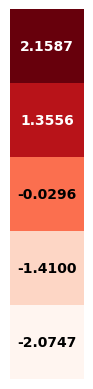

In [ ]:
data = ranking_pca.reshape(-1, 1)
plt.imshow(data, cmap="Reds")
plt.axis("off")

# Add text labels in the center of each square
n_rows = data.shape[0]
for i in range(n_rows):
    plt.text(
        0,
        i,
        f"{data[i, 0]:.4f}",
        ha="center",
        va="center",
        color="white" if data[i, 0] > data.mean() else "black",
        fontsize=10,
        weight="bold",
    )

plt.savefig("ranking_pca.svg", dpi=300, bbox_inches="tight")

In [ ]:
# Method 2: Multidimensional Scaling (MDS) - designed for distance matrices
mds = MDS(n_components=1, dissimilarity="precomputed", random_state=42)
ranking_mds = mds.fit_transform(distance_matrix).flatten()

print("Method 2: MDS")
print(f"Ranking (1D positions): {ranking_mds}")
print(f"Order: {np.argsort(ranking_mds)}")

Method 2: MDS
Ranking (1D positions): [ 0.78    0.4375 -0.665  -0.5525]
Order: [2 3 1 0]


In [ ]:
# Method 3: Principal Coordinate Analysis (PCoA) - classical MDS
# This is essentially the same as classical MDS
def pcoa(D, n_components=1):
    """Principal Coordinate Analysis (Classical MDS)"""
    n = D.shape[0]
    # Double centering
    D_sq = D**2
    row_means = D_sq.mean(axis=1, keepdims=True)
    col_means = D_sq.mean(axis=0, keepdims=True)
    grand_mean = D_sq.mean()
    B = -0.5 * (D_sq - row_means - col_means + grand_mean)

    # Eigendecomposition
    eigenvals, eigenvecs = eigh(B)
    # Sort by eigenvalue (descending)
    idx = eigenvals.argsort()[::-1]
    eigenvals = eigenvals[idx]
    eigenvecs = eigenvecs[:, idx]

    # Take first n_components
    eigenvals = eigenvals[:n_components]
    eigenvecs = eigenvecs[:, :n_components]

    # Scale by sqrt of eigenvalues
    result = eigenvecs * np.sqrt(eigenvals)
    return result.flatten()


ranking_pcoa = pcoa(distance_matrix)

print("Method 3: Principal Coordinate Analysis (PCoA)")
print(f"Ranking (1D positions): {ranking_pcoa}")
print(f"Order: {np.argsort(ranking_pcoa)}")

Method 3: Principal Coordinate Analysis (PCoA)
Ranking (1D positions): [-0.67241715 -0.50948408  0.33580885  0.84609238]
Order: [0 1 2 3]


In [ ]:
# Method 4: Spectral embedding using Laplacian
def spectral_embedding_1d(D, normalize=True):
    """1D spectral embedding from distance matrix"""
    # Convert distance to affinity (similarity)
    # Using Gaussian kernel: A = exp(-D^2 / sigma^2)
    sigma = np.median(D[D > 0])  # Use median distance as scale
    A = np.exp(-(D**2) / (2 * sigma**2))
    np.fill_diagonal(A, 0)  # No self-connections

    # Compute Laplacian
    n_objects = D.shape[0]
    if normalize:
        D_deg = np.diag(A.sum(axis=1))
        D_deg_inv_sqrt = np.diag(1.0 / np.sqrt(A.sum(axis=1)))
        L = np.eye(n_objects) - D_deg_inv_sqrt @ A @ D_deg_inv_sqrt
    else:
        D_deg = np.diag(A.sum(axis=1))
        L = D_deg - A

    # Get second smallest eigenvector (Fiedler vector)
    eigenvals, eigenvecs = eigh(L)
    idx = eigenvals.argsort()
    fiedler = eigenvecs[:, idx[1]]  # Skip first (always ~0)

    return fiedler


ranking_spectral = spectral_embedding_1d(distance_matrix)

print("Method 4: Spectral embedding (Fiedler vector)")
print(f"Ranking (1D positions): {ranking_spectral}")
print(f"Order: {np.argsort(ranking_spectral)}")

Method 4: Spectral embedding (Fiedler vector)
Ranking (1D positions): [ 0.52798839  0.4239493  -0.38567602 -0.62669711]
Order: [3 2 1 0]
